# Рейтинг шоколадных батончиков

У нас есть датасет про шоколад. В нем есть данные о различных шоколадных батончиках. На этот датасете можно обучить модель машинного обучения, но для начала данные нужно изучить и при необходимости обработать, чтобы модель лучше обучилась.

Посмотрим, что есть в датасете:




In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import re

import numpy as np
import seaborn as sns


data = pd.read_csv('/content/flavors_of_cacao.csv')

In [2]:
data.sample(10)

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
337,Cao,Bolivia,1808,2016,75%,U.S.A.,3.00,,Bolivia
497,Dandelion,Tanzania,654,2011,70%,U.S.A.,3.25,,Tanzania
388,Chocolarder,Peru + nibs,1482,2015,65%,U.K.,2.75,Criollo,Peru
1512,Soma,"Tien Giang, Black S., batch VIT60420.0",1828,2016,70%,Canada,4.00,Trinitario,Vietnam
946,Laia aka Chat-Noir,"Ivory Coast, Batch 56/100",1594,2015,75%,France,3.00,,Ivory Coast
683,Fresco,"Conacado, #223, MR, SC",1030,2013,72%,U.S.A.,3.25,,Dominican Republic
1483,"Smooth Chocolator, The",Akesson's Estate,1618,2015,65%,Australia,3.25,Trinitario,Madagascar
339,Caoni (Tulicorp),Esmeraldas,237,2008,77%,Ecuador,2.00,Forastero (Arriba),Ecuador
1547,Soma,Black Science Blend 1,607,2010,70%,Canada,3.75,"Trinitario, Nacional","DR, Ecuador, Peru"
1542,Soma,"Alto Beni, Wild Bolivian",676,2011,70%,Canada,3.50,Nacional,Bolivia


In [3]:
data.tail(10)

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
1785,Zotter,Huiwani Coop,879,2012,75%,Austria,3.00,"Criollo, Trinitario",Papua New Guinea
1786,Zotter,El Ceibo Coop,879,2012,90%,Austria,3.25,,Bolivia
1787,Zotter,Santo Domingo,879,2012,70%,Austria,3.75,,Dominican Republic
1788,Zotter,"Kongo, Highlands",883,2012,68%,Austria,3.25,Forastero,Congo
1789,Zotter,"Indianer, Raw",883,2012,58%,Austria,3.50,,
1790,Zotter,Peru,647,2011,70%,Austria,3.75,,Peru
1791,Zotter,Congo,749,2011,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,749,2011,65%,Austria,3.50,Forastero,India
1793,Zotter,Kerala State,781,2011,62%,Austria,3.25,,India
1794,Zotter,"Brazil, Mitzi Blue",486,2010,65%,Austria,3.00,,Brazil


array([[<Axes: title={'center': 'ref'}>,
        <Axes: title={'center': 'Review\nDate'}>],
       [<Axes: title={'center': 'rating'}>, <Axes: >]], dtype=object)

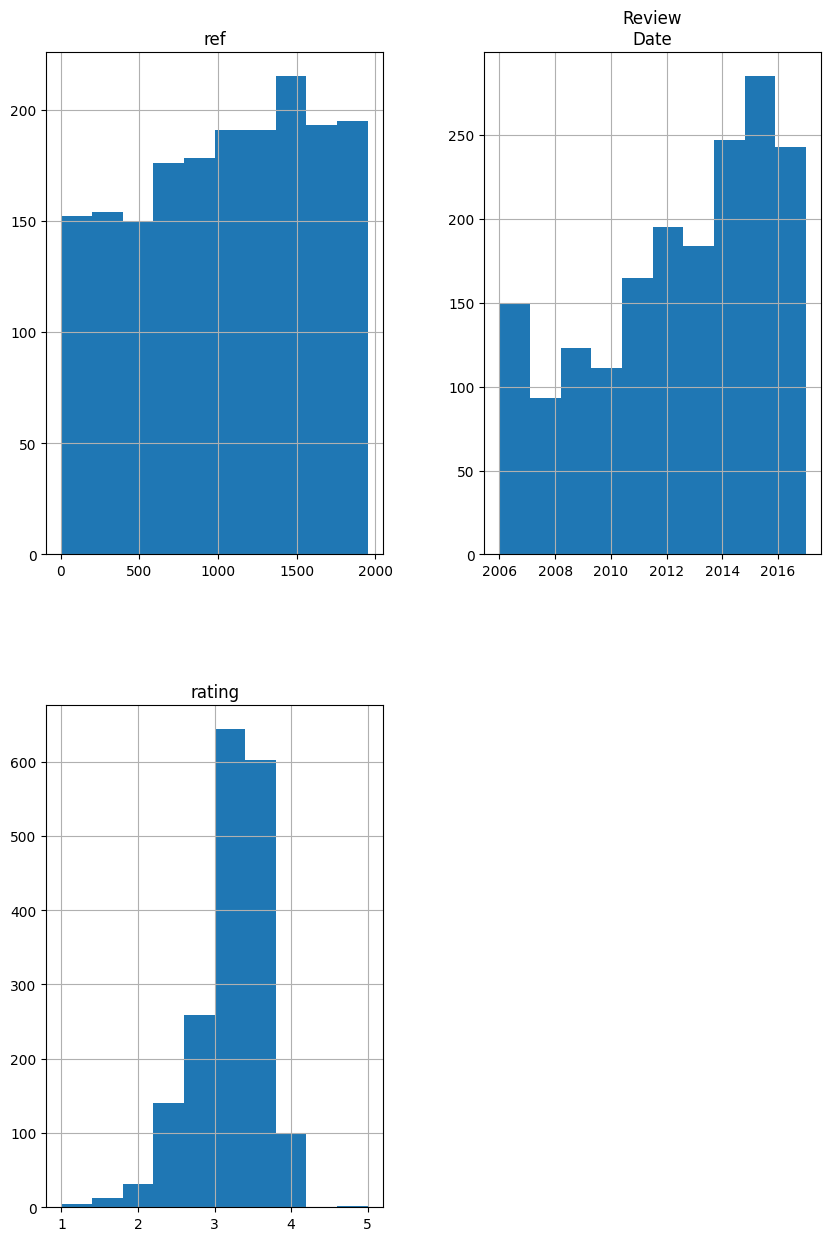

In [18]:
data.hist(figsize=(10, 15))

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company 
(Maker-if known)         1795 non-null   object 
 1   Specific Bean Origin
or Bar Name  1795 non-null   object 
 2   REF                               1795 non-null   int64  
 3   Review
Date                       1795 non-null   int64  
 4   Cocoa
Percent                     1795 non-null   object 
 5   Company
Location                  1795 non-null   object 
 6   Rating                            1795 non-null   float64
 7   Bean
Type                         1794 non-null   object 
 8   Broad Bean
Origin                 1794 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 126.3+ KB


In [6]:
data.isna().sum()

Company \n(Maker-if known)           0
Specific Bean Origin\nor Bar Name    0
REF                                  0
Review\nDate                         0
Cocoa\nPercent                       0
Company\nLocation                    0
Rating                               0
Bean\nType                           1
Broad Bean\nOrigin                   1
dtype: int64

Промежуточный вывод:

1) столбцы названы не по правилам snake_case

2) пропущенных значений всего два

3) некоторые столбцы имеют неправильный тип данных

4) выбросов нет

# Предобработка данных

1) Переименуем столбцы:

In [40]:
data.columns = [col.replace('\n', '') if '\n' in col else col for col in data.columns]
# строчка выше удаляет знак \n, потому что создатель датасета садист и зачем-то добавил его туда
data.rename(columns={'Company \n(Maker-if known)':'company_maker', 'Specific Bean Origin\nor Bar Name':'bean_or_bar_name', 'REF':'ref','Review\nDate':'review_date',
                     'Cocoa\nPercent':'cocoa_percent', 'Company\nLocation':'company_location', 'Rating':'rating', 'Bean\nType':'bean_type',
                     'Broad Bean\nOrigin':'bean_origin'}, inplace = True)
data.rename(columns={'Company (Maker-if known)':'company_maker', 'Specific Bean Originor Bar Name':'bean_or_bar_name', 'REF':'ref','ReviewDate':'review_date',
                     'CocoaPercent':'cocoa_percent', 'CompanyLocation':'company_location', 'Rating':'rating', 'BeanType':'bean_type',
                     'Broad BeanOrigin':'bean_origin'}, inplace = True)
# второй rename был добавлен по той причине, что в рандомный момент имена столбцов перестают переименовываться.
# поскольку причину выяснить мне не удалось, то единственным решением является добавить сюда еще кода
data.columns

Index(['Company (Maker-if known)', 'bean_or_bar_name', 'ref', 'review_date',
       'cocoa_percent', 'company_location', 'rating', 'bean_type',
       'bean_origin'],
      dtype='object')

In [21]:
# столбец Company (Maker-if known) вообще не переименовывается, так что придется оставить его так.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company 
(Maker-if known)  1795 non-null   object 
 1   bean_or_bar_name           1795 non-null   object 
 2   ref                        1795 non-null   int64  
 3   review_date                1795 non-null   int64  
 4   cocoa_percent              1795 non-null   object 
 5   company_location           1795 non-null   object 
 6   rating                     1795 non-null   float64
 7   bean_type                  1794 non-null   object 
 8   bean_origin                1794 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 126.3+ KB


2) Поменяем тип данных у столбца 'cocoa_percent':

In [31]:
# data['cocoa_percent'] = data['cocoa_percent'].str.replace('%', '')
# строчка выше удалили знак % из столбца. она здесь оставлена просто чтобы показать как прошел процесс преобразования.
data['cocoa_percent'] = data['cocoa_percent'].astype('float')

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company 
(Maker-if known)  1795 non-null   object 
 1   bean_or_bar_name           1795 non-null   object 
 2   ref                        1795 non-null   int64  
 3   review_date                1795 non-null   int64  
 4   cocoa_percent              1795 non-null   float64
 5   company_location           1795 non-null   object 
 6   rating                     1795 non-null   float64
 7   bean_type                  1794 non-null   object 
 8   bean_origin                1794 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 126.3+ KB


Как было показано выше, пропущенных значений всего два, и то те являются категориальными, так что их оставит.

А выбросов в числовых данных нет.

Итак, что было сделано:

1) Изменены имена столбцов

2) Изменен тип данных столбца с object на float

# Исследование данных




In [41]:
data['bean_or_bar_name'].value_counts()

bean_or_bar_name
Madagascar                        57
Peru                              45
Ecuador                           42
Dominican Republic                37
Venezuela                         21
                                  ..
Conacado, #213, DR, -C             1
Sambirano Valley, #215, MR, MC     1
Chuao, #218, MR, MC                1
Chuao, #217, DR, MC                1
Brazil, Mitzi Blue                 1
Name: count, Length: 1039, dtype: int64

In [42]:
data['company_location'].value_counts()

company_location
U.S.A.               764
France               156
Canada               125
U.K.                  96
Italy                 63
Ecuador               54
Australia             49
Belgium               40
Switzerland           38
Germany               35
Austria               26
Spain                 25
Colombia              23
Hungary               22
Venezuela             20
Japan                 17
Brazil                17
Peru                  17
Madagascar            17
New Zealand           17
Denmark               15
Vietnam               11
Scotland              10
Guatemala             10
Israel                 9
Costa Rica             9
Argentina              9
Poland                 8
Lithuania              6
Honduras               6
South Korea            5
Nicaragua              5
Sweden                 5
Domincan Republic      5
Ireland                4
Netherlands            4
Fiji                   4
Sao Tome               4
Puerto Rico            4
Mexico  

In [43]:
data['cocoa_percent'].value_counts()

cocoa_percent
70%      672
75%      222
72%      189
65%       78
80%       72
74%       50
68%       47
60%       43
73%       40
85%       36
64%       34
77%       33
71%       31
67%       27
76%       23
66%       23
100%      20
82%       17
78%       17
55%       16
62%       14
63%       12
69%       10
90%        8
61%        8
88%        8
58%        8
81%        5
83%        4
84%        4
72.5%      4
91%        3
56%        2
73.5%      2
99%        2
89%        2
53%        1
46%        1
60.5%      1
57%        1
79%        1
86%        1
50%        1
42%        1
87%        1
Name: count, dtype: int64

In [44]:
data['bean_origin'].value_counts()

bean_origin
Venezuela                214
Ecuador                  193
Peru                     165
Madagascar               145
Dominican Republic       141
                        ... 
Peru, Belize               1
Peru, Mad., Dom. Rep.      1
PNG, Vanuatu, Mad          1
Trinidad, Ecuador          1
Venezuela, Carribean       1
Name: count, Length: 100, dtype: int64

<Axes: ylabel='Frequency'>

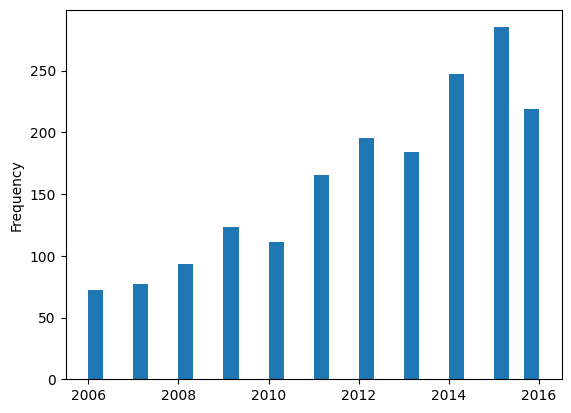

In [46]:
data['review_date'].sort_values().plot(y='review_date', kind='hist', bins=30, range=(2006, 2016))

<Axes: ylabel='Frequency'>

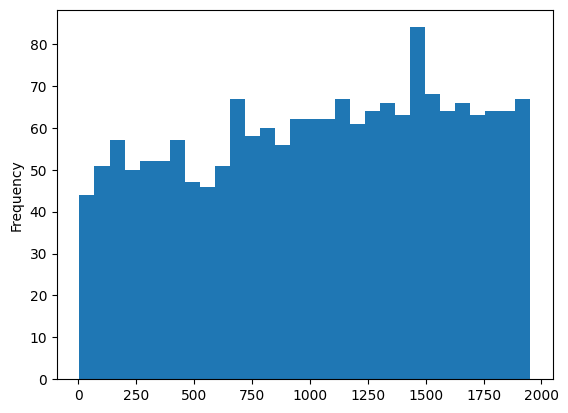

In [48]:
data['ref'].sort_values().plot(y='ref', kind='hist', bins=30, range=(5, 1952))

Выводы:

1) Самый распространенный конкретный регион для батончиков - Мадагаскар. (Примечание: в описании датасета автор к этому столбцу пишет: The specific geo-region of origin for the bar. Как еще это можно интерпретировать я не знаю.)

2) Больше всего компаний по производству шоколадных батончиков находится в США.

3) Шоколадки с 70% содержанием какао - самые распространенные (в датасете по крайне мере).

4) Какао-бобы чаще всего берутся из Венесуэлы.

5) Больше всего оценок шоколадных батончиков было сделано в 2015 году.

6) ref - значение, связанное с датой добавления шоколадки в датасет. Чем значение выше, тем недавнее батончик был добавлен. На последнем графике можно примерно оценить сколько шоколадок было добавлено и с какой частотой за все существование датасета.

# Построение модели машинного обучения

Посколько здесь представлены категориальные типы данных, то для дальнейшей работы их нужно перевести в бинарные. Это выполняет последняя строчка с методом get_dummies:

In [9]:
target = data['rating']
features = data.drop('rating', axis=1)
features = pd.get_dummies(features)

In [10]:
target

0       3.75
1       2.75
2       3.00
3       3.50
4       3.50
        ... 
1790    3.75
1791    3.00
1792    3.50
1793    3.25
1794    3.00
Name: rating, Length: 1795, dtype: float64

In [11]:
features

,ref,Review\nDate,Company \n(Maker-if known)_A. Morin,Company \n(Maker-if known)_AMMA,Company \n(Maker-if known)_Acalli,Company \n(Maker-if known)_Adi,Company \n(Maker-if known)_Aequare (Gianduja),Company \n(Maker-if known)_Ah Cacao,Company \n(Maker-if known)_Akesson's (Pralus),Company \n(Maker-if known)_Alain Ducasse,...,Broad Bean\nOrigin_Venezuela,"Broad Bean\nOrigin_Venezuela, Carribean","Broad Bean\nOrigin_Venezuela, Dom. Rep.","Broad Bean\nOrigin_Venezuela, Ghana","Broad Bean\nOrigin_Venezuela, Java","Broad Bean\nOrigin_Venezuela, Trinidad",Broad Bean\nOrigin_Venezuela/ Ghana,Broad Bean\nOrigin_Vietnam,Broad Bean\nOrigin_West Africa,Broad Bean\nOrigin_
0,1876,2016,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1676,2015,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1676,2015,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1680,2015,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1704,2015,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,647,2011,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1791,749,2011,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1792,749,2011,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1793,781,2011,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Таблица выше показывает результат применения метода get_dummies:

In [12]:
features, features_train, target, target_train = train_test_split(
    features, target, test_size=0.4, random_state=12345)

features_test, features_valid, target_test, target_valid = train_test_split(
    features, target, train_size=0.5, random_state=12345)



In [34]:
features_train.shape

(718, 1703)

In [35]:
features_test.shape

(538, 1703)

In [36]:
features_valid.shape

(539, 1703)

Здесь нужно использовать линейную регрессию, поскольку целевая переменная является непрерывной (а еще потому что колаб начинает ругаться на дерево решений...хотя поэтому он и ругается, это логично):

In [16]:
%time
best_model_lr = None
best_accuracy_lr = 0
for depth in tqdm(range(1, 11)):
  for i in range(10):
      model_lr = LinearRegression(fit_intercept=True)
      model_lr.fit(features_train, target_train)
      predictions_lr = model_lr.predict(features_valid)
      diff = np.abs(target_valid - predictions_lr) # это массив, которые содержит все разности между целевыми значениями и предсказаниями
      correct_preds = np.sum(diff < 0.5)  # предсказание считается правильным, если разница меньше 0.5
      accuracy_lr = correct_preds / len(target_valid) * 10 # точность высчитывается путем деления кол-ва правильных пресказаний на общее кол-во целевых значений
      if accuracy_lr > best_accuracy_lr:
        best_model_lr = model_lr
        best_accuracy_lr =accuracy_lr
print(f'Лучший результат: {best_accuracy_lr:.2f}')


CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 7.39 µs


100%|██████████| 10/10 [01:11<00:00,  7.15s/it]

Лучший результат: 0.89


# Заключение

1) Был изучен датасет про шоколадные батончики, рассмотрены входящие в него данные

2) Данные были обработаны: изменены типы данных и имена столбцов в датасете

3) Была написана модель машинного обучения, в которой использовалась линейная регрессия. Точность модели составила 89%, время на обучение - чуть больше минуты.